# END-TO-END RETAIL ANALYTICS WORKFLOW
### Customer Segmentation Using RFM & K-Means Clustering

> **Project Objective:** Clean raw transactional data, isolate product returns, handle heavily skewed distributions, and build an optimal 4-cluster K-Means model to discover actionable customer purchasing behaviors.

# # 1. DATA INGESTION & AUDIT
> **Focus:** Load the raw Excel sheet, review data types, identify missing values, and check statistical summaries. 1. DATA INGESTION & AUDIT

In [2]:
import pandas as pd

file_path = r"C:\Users\a\Downloads\customer.xlsx\customer.xlsx"
df = pd.read_excel(file_path, sheet_name="Online Retail")

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [4]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
print(df[['Quantity','UnitPrice']].describe())

            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000


# # 2. DATA CLEANING & PARTITIONING
> **Focus:** Separate completed sales from returns, drop missing customer IDs, calculate financial totals, and export clean staging CSVs.

In [7]:
df_sales = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df_sales = df_sales.dropna(subset=['CustomerID'])

df_returns = df[(df['Quantity'] < 0) | (df['InvoiceNo'].astype(str).str.startswith('C'))]
df_returns = df_returns.dropna(subset=['CustomerID'])

print("Sales table shape:", df_sales.shape)
print("Returns table shape:", df_returns.shape)

Sales table shape: (397884, 8)
Returns table shape: (8905, 8)


In [8]:
df_sales['InvoiceDate']=pd.to_datetime(df_sales['InvoiceDate'])

In [9]:
df_sales['InvoiceYear']=df_sales['InvoiceDate'].dt.year
df_sales['InvoiceMonth']=df_sales['InvoiceDate'].dt.month
df_sales['TotalCost']=df_sales['Quantity']*df_sales['UnitPrice']

In [10]:
df_returns['InvoiceDate']=pd.to_datetime(df_returns['InvoiceDate'])
df_returns['TotalLoss']=df_returns['Quantity']*df_returns['UnitPrice']

In [11]:
df_sales.to_csv("clean_sales.csv",index=False)
df_returns.to_csv("clean_returns.csv",index=False)

# # 3. RFM FEATURE AGGREGATION
> **Focus:** Calculate Recency, Frequency, and Monetary values for each unique customer using our sales dataset.

In [27]:
snapshot_date = df_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_df = df_sales.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, 
    'InvoiceNo': 'nunique',                                 
    'TotalCost': 'sum'                                     
}).reset_index()

rfm_df.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalCost': 'Monetary'
}, inplace=True)

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


# # 4. ENVIRONMENT INSTALLATION & TRANSFORMATION
> **Focus:** Install required machine learning packages, stabilize outlier skewness via log-transformation, and apply StandardScaler.

In [16]:
!pip install scikit-learn --default-timeout=1000

  Using cached scikit_learn-1.0.2-cp37-cp37m-win_amd64.whl (7.1 MB)
  Using cached threadpoolctl-3.1.0-py3-none-any.whl (14 kB)
  Using cached joblib-1.3.2-py3-none-any.whl (302 kB)
     --------------------------------------- 34.1/34.1 MB 68.3 kB/s eta 0:00:00


In [28]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = rfm_df[['Recency', 'Frequency', 'Monetary']].copy()
X['Recency'] = np.log1p(X['Recency'])
X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary'] = np.log1p(X['Monetary'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm_df['Cluster'] = kmeans.fit_predict(X_scaled)

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,2
2,12348.0,75,4,1797.24,3
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


# # 5. SEGMENT PROFILING & REPORTING
> **Focus:** Aggregate cluster metrics to calculate segment baseline statistics and export customer records to a staging file.

In [29]:
cluster_analysis = rfm_df.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'CustomerID': 'Customer Count'}).round(2)

cluster_analysis

,Customer Count,Recency,Frequency,Monetary
Cluster,,,,
0,832,17.67,2.19,561.92
1,1623,181.32,1.32,341.84
2,714,12.16,13.74,8093.36
3,1169,71.66,4.08,1805.33


In [30]:
rfm_df.to_csv("customer_segmented_rfm.csv", index=False)
print("Segmented customer dataset saved successfully!")

Segmented customer dataset saved successfully!


# # 6. CLUSTER DISTRIBUTION VISUALIZATION
> **Focus:** Generate professional comparative scatter plots evaluating customer spend against order velocity and recency vectors.

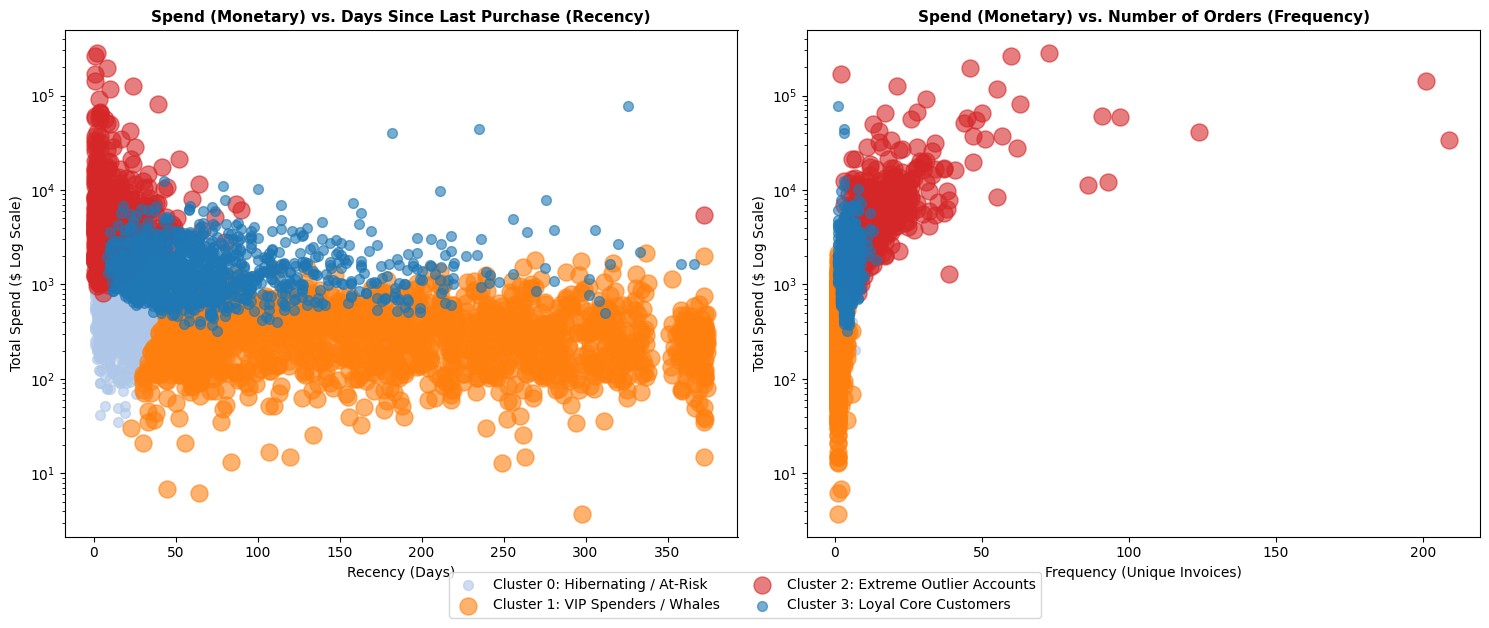

In [31]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = {0: '#aec7e8', 1: '#ff7f0e', 2: '#d62728', 3: '#1f77b4'}
labels = {
    0: 'Cluster 0: Hibernating / At-Risk',
    1: 'Cluster 1: VIP Spenders / Whales',
    2: 'Cluster 2: Extreme Outlier Accounts',
    3: 'Cluster 3: Loyal Core Customers'
}

for cluster, group in rfm_df.groupby('Cluster'):
    ax1.scatter(group['Recency'], group['Monetary'], color=colors[cluster], 
                label=labels[cluster], alpha=0.6, s=50 if cluster not in [1,2] else 150)
ax1.set_title('Spend (Monetary) vs. Days Since Last Purchase (Recency)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Recency (Days)')
ax1.set_ylabel('Total Spend ($ Log Scale)')
ax1.set_yscale('log')

for cluster, group in rfm_df.groupby('Cluster'):
    ax2.scatter(group['Frequency'], group['Monetary'], color=colors[cluster], 
                alpha=0.6, s=50 if cluster not in [1,2] else 150)
ax2.set_title('Spend (Monetary) vs. Number of Orders (Frequency)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Frequency (Unique Invoices)')
ax2.set_ylabel('Total Spend ($ Log Scale)')
ax2.set_yscale('log')

plt.tight_layout()
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=10, frameon=True)
plt.savefig('customer_clusters_chart.png', dpi=300, bbox_inches='tight')
plt.show()